# Advection-Reaction-Diffusion equations: Allen-Cahn equation
## Dataset generation

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, ConcatDataset, Subset
from torch import Tensor
from generate import generate_from_config, PDE_KEYS, PDE_VALUES, IC_KEYS, IC_VALUES, TIMES
from plot_utils import plot_points, plot_points_grid
from pde_utils import key_str, ic_key_str
from generate import X, U
from typing import Tuple, List
from data_utils import extract_targets, extract_boundary, extract_interior
import yaml
# ------------------------
SEED = 42
PDE = "AdvectionReactionDiffusion/AllenCahn"
PDE_NAME = "Advection-Reaction-Diffusion"

TO_FIX = [] # ["IC", "D"] ["IC"] ["D"] []
FIX_SOURCES_POSITION = False
N_REPETITIONS = 1 # If x is fixed, generate for N_REPETITIONS different x
N_TASKS = 5 # If x is not fixed (x = IC|D|<IC, D>), sample N_TASKS different x

# ++++++++++ Initial conditions: ++++++++++
# Base value
U0 = 0.0

GAUSSIAN_SOURCES = True
PERIODIC_CIRCLES = False
PERIODIC_VALLEYS = False
PERIODIC_STRIPES = False
PERIODIC_GRID = False
UNIFORM_NOISE = False

# GAUSSIAN_SOURCES
STDDEV_MIN, STDDEV_MAX = 0.2, 0.5#0.5, 1.0
AMP_MIN, AMP_MAX = -1.0, 1.0#0.1, 0.5
N_SOURCES = [5]
EDGE = 0.0 # Edge thickness for the generation of the source centers

# PERIODIC_*
A_MIN, A_MAX = 1, 1
B_MIN, B_MAX = 10, 10
C_MIN, C_MAX = 1, 1
D_MIN, D_MAX = 1, 1

# UNIFORM_NOISE
NOISE_MIN, NOISE_MAX = -1, 1

# +++++++++++++++++++++++++++++++++++++++++++

# Time range
T_MIN, T_MAX = 0.0, 1.0

# Time instants to store
TIME_SAMPLING = "Const" # Const Log
N_TIME_SAMPLES = 10
SNAPSHOT_START = 0.0 #0.92#0.0
STEP_STR = "_0-9"

# Domain shape
SHAPE = "rectangle" # circle rectangle

# Spatial ranges
X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0

# Radius of the circle for circular domains
RADIUS = 1.0

# Edge thickness for the generation of the source centers
EDGE = 0.0

BC_R = {
    "left": ["Neumann", 0.0],
    "right": ["Neumann", 0.0],
    "top": ["Neumann", 0.0],
    "bottom": ["Neumann", 0.0]
}
BC_C = {"mode": "Neumann", "value": 0.0}
BC_STR = "NeumannBC"

# Spatio-temporal grid resolution
DT = 0.02
DX = 0.02
DY = 0.02
CELL_SIZE = 0.02

# Spatial subsample size per time instant
SAMPLES_PER_T = 6144

# Spatial subsample size per time instant for dev, intra-test and val (train = dev - val)
N_DEV_SAMPLES_PER_T = 2048
N_INTRA_TEST_SAMPLES_PER_T = 512
N_VAL_SAMPLES_PER_T = 512
# Diffusion coefficient generation range
DIFF_MIN, DIFF_MAX = 0.01, 0.01# 0.0, 1.0
REACTION_COEFF_MIN, REACTION_COEFF_MAX = 1.0, 1.0#1.5, 1.5#1.0, 1.0

# Name of the .pth dataset file
DATASET_NAME = "full_datasets"
# ----------------------------------------------
if "IC" in TO_FIX:
    STR = "FixIC"
else:
    STR = "VaryIC"
if "D" in TO_FIX:
    STR += "_FixD"
else:
    STR += "_VaryD"

if SHAPE == "circle":
    BC = BC_C
else:
    BC = BC_R

### Functions

In [2]:
def subsample(
    datasets: List[ConcatDataset],
    n_dev_samples: int,
    n_test_samples: int,
    seed=42
    ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:

    dev_reduced_datasets = []
    test_reduced_datasets = []
    last_seed = seed

    dev_indicess = []
    test_indicess = []
    
    for concat_ds in datasets:
        seeds = [last_seed+i for i in range(len(concat_ds.datasets))]
        last_seed = seeds[-1]
        dev_reduced_concat_ds = []
        test_reduced_concat_ds = []
        dev_indices = []
        test_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            dev_indices.append(indices[:n_dev_samples])
            test_indices.append(indices[n_dev_samples:n_dev_samples+n_test_samples])
            #dev_reduced_cols = [col[dev_indices] for col in ds.tensors]
            #dev_reduced_concat_ds.append(TensorDataset(*dev_reduced_cols))
            dev_reduced_concat_ds.append(Subset(ds, dev_indices[-1]))
            #test_reduced_cols = [col[test_indices] for col in ds.tensors]
            #test_reduced_concat_ds.append(TensorDataset(*test_reduced_cols))
            test_reduced_concat_ds.append(Subset(ds, test_indices[-1]))
        dev_indicess.append(dev_indices)
        test_indicess.append(test_indices)
        dev_reduced_datasets.append(ConcatDataset(dev_reduced_concat_ds))
        test_reduced_datasets.append(ConcatDataset(test_reduced_concat_ds))
    return dev_reduced_datasets, dev_indicess, test_reduced_datasets, test_indicess

def subsample_single(
    dataset: ConcatDataset, 
    n_samples: int, 
    seed: int = 42
) -> ConcatDataset:
    reduced_dataset = []
    seeds = [seed+i for i in range(len(dataset.datasets))]
    for ds, seed in zip(dataset.datasets, seeds):
        torch.manual_seed(seed)
        indices = torch.randperm(len(ds))[:n_samples]
        reduced_cols = [col[indices] for col in ds.tensors]
        reduced_dataset.append(TensorDataset(*reduced_cols))
    return ConcatDataset(reduced_dataset)

def subsample_bd(
    dataset: ConcatDataset, 
    n_samples: int, 
    seed: int = 42
) -> ConcatDataset:
    reduced_dataset = []
    seeds = [seed+i for i in range(len(dataset.datasets))]
    for ds, seed in zip(dataset.datasets, seeds):
        bd = extract_boundary(ds)
        torch.manual_seed(seed)
        indices = torch.randperm(len(bd))[:n_samples]
        reduced_cols = [col[indices] for col in bd.tensors]
        reduced_dataset.append(TensorDataset(*reduced_cols))
    return ConcatDataset(reduced_dataset)

def split_train_val(
        dev_datasets: List[ConcatDataset],
        n_val_samples: int,
        seed: int = 42
        ) -> Tuple[List[ConcatDataset], List[List[Tensor]], List[ConcatDataset], List[List[Tensor]]]:
    
    val_datasets = []
    train_datasets = []

    train_indicess = []
    val_indicess = []
    
    for j, concat_ds in enumerate(dev_datasets):
        seeds = [seed+i*j for i in range(len(concat_ds.datasets))]
        train_concat_ds = []
        val_concat_ds = []
        train_indices = []
        val_indices = []
        for ds, seed in zip(concat_ds.datasets, seeds):
            torch.manual_seed(seed)
            indices = torch.randperm(len(ds))
            val_indices.append(indices[:n_val_samples])
            train_indices.append(indices[n_val_samples:])
            #train_cols = [col[train_indices] for col in ds.tensors]
            #train_concat_ds.append(TensorDataset(*train_cols))
            train_concat_ds.append(Subset(ds, train_indices[-1]))
            #val_cols = [col[val_indices] for col in ds.tensors]
            #val_concat_ds.append(TensorDataset(*val_cols))
            val_concat_ds.append(Subset(ds, val_indices[-1]))
        train_indicess.append(train_indices)
        val_indicess.append(val_indices)
        train_datasets.append(ConcatDataset(train_concat_ds))
        val_datasets.append(ConcatDataset(val_concat_ds))
    return train_datasets, train_indicess, val_datasets, val_indicess

def load_subsets(
        indicesss: Tensor|List[List[Tensor]],
        dataset: List[ConcatDataset[TensorDataset]]
    ) -> List[ConcatDataset[Subset]]:
    datasetss = []
    for indicess, task_ds in zip(indicesss, dataset):
        datasets = []
        for indices, time_ds in zip(indicess, task_ds.datasets):
            datasets.append(Subset(time_ds, indices))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

def load_datasets(
        indicesss: Tensor|List[List[Tensor]],
        dataset: List[ConcatDataset[TensorDataset]]
    ) -> List[ConcatDataset[TensorDataset]]:
    datasetss = []
    for cds, indicess in zip(dataset, indicesss):
        datasets = []
        for ds, indices in zip(cds.datasets, indicess):
            cols = [col[indices] for col in ds.tensors]
            datasets.append(TensorDataset(*cols))
        datasetss.append(ConcatDataset(datasets))
    return datasetss

### Data generation

In [ ]:
os.makedirs(f"{PDE}/data", exist_ok=True)
os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}", exist_ok=True)
os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}", exist_ok=True)

for n_sources in N_SOURCES:

    os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}", exist_ok=True)
    
    for j in range(N_REPETITIONS):

        os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}", exist_ok=True)
        os.makedirs(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/plots", exist_ok=True)

        np.random.seed(SEED + j)
        
        As = np.array([0 for _ in range(N_TASKS)])
        Axs = np.array([0 for _ in range(N_TASKS)])
        Ays = np.array([0 for _ in range(N_TASKS)])
        Bs = np.array([0 for _ in range(N_TASKS)])
        Bxs = np.array([0 for _ in range(N_TASKS)])
        Bys = np.array([0 for _ in range(N_TASKS)])
        Cxs = np.array([0 for _ in range(N_TASKS)])
        Cys = np.array([0 for _ in range(N_TASKS)])
        Ds = np.array([0 for _ in range(N_TASKS)])
        centers = np.array([0 for _ in range(N_TASKS)])
        amps = np.array([0 for _ in range(N_TASKS)])
        sigmas = np.array([0 for _ in range(N_TASKS)])

        if "IC" in TO_FIX:
            if GAUSSIAN_SOURCES:
                centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources, 2))
                amps = np.random.uniform(AMP_MIN, AMP_MAX, size=(n_sources, 1))
                sigmas = np.random.uniform(STDDEV_MIN, STDDEV_MAX, size=(n_sources, 1))
                centers = np.concatenate([centers for _ in range(N_TASKS)], axis=0)
                amps = np.concatenate([amps for _ in range(N_TASKS)], axis=0)
                sigmas = np.concatenate([sigmas for _ in range(N_TASKS)], axis=0)
            if PERIODIC_CIRCLES:
                A = np.random.uniform(A_MIN, A_MAX, size=(1, 1))
                B = np.random.uniform(B_MIN, B_MAX, size=(1, 1))
                Cx, Cy = np.random.uniform(C_MIN, C_MAX, size=(2, 1))
                D = np.random.uniform(D_MIN, D_MAX, size=(1, 1))
                As = np.array([A for _ in range(N_TASKS)])
                Bs = np.array([B for _ in range(N_TASKS)])
                Cxs = np.array([Cx for _ in range(N_TASKS)])
                Cys = np.array([Cy for _ in range(N_TASKS)])
                Ds = np.array([D for _ in range(N_TASKS)])
            if PERIODIC_VALLEYS:
                A = np.random.uniform(A_MIN, A_MAX, size=(1, 1))
                B = np.random.uniform(B_MIN, B_MAX, size=(1, 1))
                As = np.array([A for _ in range(N_TASKS)])
                Bs = np.array([B for _ in range(N_TASKS)])
            if PERIODIC_STRIPES:
                A = np.random.uniform(A_MIN, A_MAX, size=(1, 1))
                Bx, By = np.random.uniform(B_MIN, B_MAX, size=(2, 1))
                As = np.array([A for _ in range(N_TASKS)])
                Bxs = np.array([Bx for _ in range(N_TASKS)])
                Bys = np.array([By for _ in range(N_TASKS)])
            if PERIODIC_GRID:
                Ax, Ay = np.random.uniform(A_MIN, A_MAX, size=(2, 1))
                Bx, By = np.random.uniform(B_MIN, B_MAX, size=(2, 1))
                Cx, Cy = np.random.uniform(C_MIN, C_MAX, size=(2, 1))
                Axs = np.array([Ax for _ in range(N_TASKS)])
                Ays = np.array([Ay for _ in range(N_TASKS)])
                Bxs = np.array([Bx for _ in range(N_TASKS)])
                Bys = np.array([By for _ in range(N_TASKS)])
                Cxs = np.array([Cx for _ in range(N_TASKS)])
                Cys = np.array([Cy for _ in range(N_TASKS)])
        else:
            if GAUSSIAN_SOURCES:
                if FIX_SOURCES_POSITION:
                    centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources, 2))
                    centers = np.concatenate([centers for _ in range(N_TASKS)], axis=0)
                else:
                    centers = np.random.uniform([X_MIN+EDGE, Y_MIN+EDGE], [X_MAX-EDGE, Y_MAX-EDGE], size=(n_sources * N_TASKS, 2))
                amps = np.random.uniform(AMP_MIN, AMP_MAX, size=(n_sources * N_TASKS, 1))
                sigmas = np.random.uniform(STDDEV_MIN, STDDEV_MAX, size=(n_sources * N_TASKS, 1))
            if PERIODIC_CIRCLES:
                As = np.random.uniform(A_MIN, A_MAX, size=(1, N_TASKS))
                Bs = np.random.uniform(B_MIN, B_MAX, size=(1, N_TASKS))
                Cxs, Cys = np.random.uniform(C_MIN, C_MAX, size=(2, N_TASKS))
                Ds = np.random.uniform(D_MIN, D_MAX, size=(1, N_TASKS))
            if PERIODIC_VALLEYS:
                As = np.random.uniform(A_MIN, A_MAX, size=(1, N_TASKS))
                Bs = np.random.uniform(B_MIN, B_MAX, size=(1, N_TASKS))
            if PERIODIC_STRIPES:
                As = np.random.uniform(A_MIN, A_MAX, size=(1, N_TASKS))
                Bxs, Bys = np.random.uniform(B_MIN, B_MAX, size=(2, N_TASKS))
            if PERIODIC_GRID:
                Axs, Ays = np.random.uniform(A_MIN, A_MAX, size=(2, N_TASKS))
                Bxs, Bys = np.random.uniform(B_MIN, B_MAX, size=(2, N_TASKS))
                Cxs, Cys = np.random.uniform(C_MIN, C_MAX, size=(2, N_TASKS))

        if "D" in TO_FIX:
            lam = np.random.uniform(DIFF_MIN, DIFF_MAX, size=(1, 1))
            lams = np.array([lam for _ in range(N_TASKS)])
        else:
            lams = np.random.uniform(DIFF_MIN, DIFF_MAX, size=(N_TASKS, 1))
        
        if "A" in TO_FIX:
            reaction_coeff = np.random.uniform(REACTION_COEFF_MIN, REACTION_COEFF_MAX, size=(1, 1))
            reaction_coeffs = np.array([reaction_coeff for _ in range(N_TASKS)])
        else:
            reaction_coeffs = np.random.uniform(REACTION_COEFF_MIN, REACTION_COEFF_MAX, size=(N_TASKS, 1))

        centerss = [[] for _ in range(N_TASKS)]
        ampss = [[] for _ in range(N_TASKS)]
        sigmass = [[] for _ in range(N_TASKS)]

        for i in range(N_TASKS):
            centerss[i] = centers[i*n_sources : (i+1)*n_sources]
            ampss[i] = amps[i*n_sources : (i+1)*n_sources]
            sigmass[i] = sigmas[i*n_sources : (i+1)*n_sources]

        ranges = {
            "x": [X_MIN, X_MAX], 
            "y": [Y_MIN, Y_MAX]
        }
        steps = {
            "dx": DX,
            "dy": DY
        }
        circle = {
            "cell_size": CELL_SIZE, 
            "radius": RADIUS
        }

        space = {
            "mode": "grid",
            "shape": SHAPE,
            "ranges": ranges,
            "steps": steps,
            "circle": circle
        }
        
        if TIME_SAMPLING == "Const":
            time = {"t": [T_MIN, T_MAX], "dt": DT, "n_snapshots": N_TIME_SAMPLES, "snapshot_start": SNAPSHOT_START}
        elif TIME_SAMPLING == "Log":
            time = {"t": [T_MIN, T_MAX], "dt": DT, "snapshots": 2 * np.logspace(start=-2, stop=0, num=N_TIME_SAMPLES)}

        config_dict = {
            "PDE": PDE_NAME,
            "space": space,
            "time": time,
            "seed": SEED,
            "boundary_conditions": BC
        }

        initial_conditions = {
            "u0": U0,
            "gaussian": GAUSSIAN_SOURCES,
            "periodic_circles": PERIODIC_CIRCLES,
            "periodic_valleys": PERIODIC_VALLEYS,
            "periodic_stripes": PERIODIC_STRIPES,
            "periodic_grid": PERIODIC_GRID,
            "uniform_noise": UNIFORM_NOISE,
            "min_noise": NOISE_MIN,
            "max_noise": NOISE_MAX
        }

        full_datasets = []

        for k, (centers, amps, sigmas, A, Ax, Ay, B, Bx, By, Cx, Cy, D, lam, reaction_coeff) in enumerate(zip(centerss, ampss, sigmass, As, Axs, Ays, Bs, Bxs, Bys, Cxs, Cys, Ds, lams, reaction_coeffs)):

            for i, (center, amp, sigma) in enumerate(zip(centers, amps, sigmas)):
                initial_conditions[f"xc{i}"] = center[0]
                initial_conditions[f"yc{i}"] = center[1]
                initial_conditions[f"amp{i}"] = amp
                initial_conditions[f"sigma{i}"] = sigma
            initial_conditions["A"] = A
            initial_conditions["Ax"] = Ax
            initial_conditions["Ay"] = Ay
            initial_conditions["B"] = B
            initial_conditions["Bx"] = Bx
            initial_conditions["By"] = By
            initial_conditions["Cx"] = Cx
            initial_conditions["Cy"] = Cy
            initial_conditions["D"] = D
            config_dict["initial_conditions"] = initial_conditions

            config_dict["parameters"] = {
                "D": lam,
                "A": reaction_coeff,
                "source_mode": "AllenCahn"
            }

            full_datasets.append(
                subsample_single(
                    dataset=generate_from_config(config_dict),
                    n_samples=SAMPLES_PER_T,
                    seed=SEED
                )
            )

            to_save = {
                "initial_conditions": {
                    "u0": U0,
                    "gaussian": GAUSSIAN_SOURCES,
                    "periodic_circles": PERIODIC_CIRCLES,
                    "periodic_valleys": PERIODIC_VALLEYS,
                    "periodic_stipes": PERIODIC_STRIPES,
                    "periodic_grid": PERIODIC_GRID,
                    "uniform_noise": UNIFORM_NOISE,
                    "noise_min": NOISE_MAX,
                    "noise_max": NOISE_MIN,
                    "amps": amps.flatten().tolist(),
                    "sigmas": sigmas.flatten().tolist(),
                    "As": As.flatten().tolist(),
                    "Axs": Axs.flatten().tolist(),
                    "Ays": Ays.flatten().tolist(),
                    "Bs": Bs.flatten().tolist(),
                    "Bxs": Bxs.flatten().tolist(),
                    "Bys": Bys.flatten().tolist(),
                    "Ds": Ds.flatten().tolist()
                },
                "parameters": {
                    "D": lams.flatten().tolist(),
                    "A": reaction_coeffs.flatten().tolist()
                }
            }

            with open(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/sample{k}.yaml", "w") as f:
                yaml.dump(to_save, f)

        # Save the datasets list as a ConcatDataset
        torch.save(ConcatDataset(full_datasets), f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/{DATASET_NAME}.pth")
        del full_datasets

10


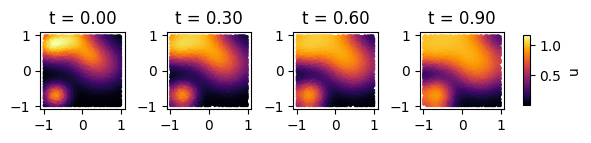

10


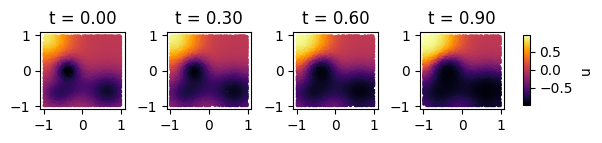

10


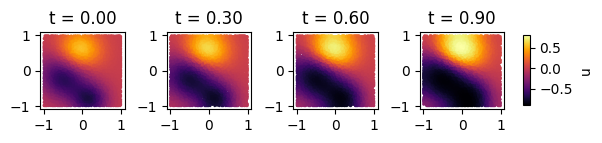

10


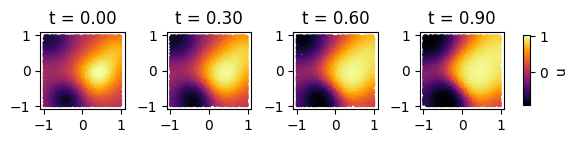

10


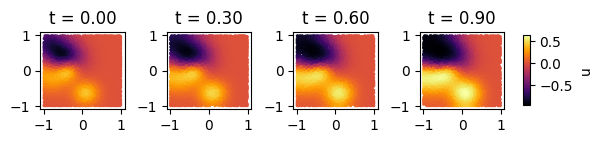

In [3]:
reps = [0]
samples = [0, 1, 2, 3, 4]
n_sources = N_SOURCES[0]
ts = [0, 3, 6, 9]
# -------------
for rep in reps:
    for sample in samples:
        titles = f"sample {sample}\n"
        datasets = torch.load(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{rep}/{DATASET_NAME}.pth", weights_only=False).datasets[sample]
        print(len(datasets.datasets))

        for key_id, key_val in zip(
            datasets.datasets[0].tensors[IC_KEYS][0],
            datasets.datasets[0].tensors[IC_VALUES][0]
            ):
            if key_id != -1:
                key_name = ic_key_str(key_id, "Advection-Reaction-Diffusion")
                titles += f"{key_name} = {key_val:.2f}\n"
        for key_id, key_val in zip(
            datasets.datasets[0].tensors[PDE_KEYS][0],
            datasets.datasets[0].tensors[PDE_VALUES][0]
            ):
            if key_id != -1:
                key_name = key_str(key_id, "Advection-Reaction-Diffusion")
                titles += f"{key_name} = {key_val:.2f}\n"

        subtitles = [f"t = {datasets.datasets[t].tensors[TIMES][0].item():.2f}" for t in ts]
        datas = [datasets.datasets[t] for t in range(max(ts)+1)]

        del datasets

        vmin = min([datas[t].tensors[U].min() for t in ts])
        vmax = max([datas[t].tensors[U].max() for t in ts])

        # Plot
        figsize = (len(ts) * 1.6, 1.0)
        #vmin = min([dsl.datasets[t].tensors[U].min() for dsl in datasets])
        #vmax = max([dsl.datasets[t].tensors[U].max() for dsl in datasets])
        plot_points(
            dataset=[datas[t] for t in ts],#[ds.datasets[t] for ds in datasets],
            points_idx=X,
            labels_idx=U,
            #title=f"Sample {sample}",
            #caption=titles,
            subtitles=subtitles,
            single_row=True,
            cmap="inferno",
            figsize=figsize,
            vmin=len(datas)*[vmin],
            vmax=len(datas)*[vmax],
            save=True,
            dst_file=f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{rep}/plots/sample{sample}.png",
            show=True
        )
        del datas

In [5]:
for n_sources in N_SOURCES:
    for j in range(N_REPETITIONS):
        datasets = torch.load(f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/{DATASET_NAME}.pth", weights_only=False).datasets

        dev_datasets, dev_indices, _, intra_test_indices = subsample(
            datasets,
            N_DEV_SAMPLES_PER_T,
            N_INTRA_TEST_SAMPLES_PER_T,
            seed=SEED
        )
        del datasets

        _, train_indices, _, val_indices = split_train_val(
            dev_datasets,
            N_VAL_SAMPLES_PER_T,
            seed=SEED
        )
        del dev_datasets

        n_tasks = len(train_indices) # number of tasks
        n_test_tasks = 0 #int(0.2 * n_tasks)
        n_train_tasks = n_tasks - n_test_tasks

        if n_test_tasks != 0:
            inter_test_indices = dev_indices[n_train_tasks:]

        dev_indices = dev_indices[:n_train_tasks]
        train_indices = train_indices[:n_train_tasks]
        val_indices = val_indices[:n_train_tasks]
        intra_test_indices = intra_test_indices[:n_train_tasks]

        torch.save(dev_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/dev_indices.pth")
        torch.save(train_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/train_indices.pth")
        torch.save(val_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/val_indices.pth")
        torch.save(intra_test_indices, f"{PDE}/data/{BC_STR}/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep{STEP_STR}/rep{j}/intra_test_indices.pth")
        #torch.save(inter_test_indices, f"{PDE}/data/{SHAPE}/{STR}/{n_sources}sources_{TIME_SAMPLING}TimeStep/rep{j}/inter_test_indices.pth")

print(f"|dev| = {len(dev_indices[0][0])} spatial points x {len(dev_indices[0])} temporal points x {len(dev_indices)} tasks")
print(f"|train| = {len(train_indices[0][0])} spatial points x {len(train_indices[0])} temporal points x {len(train_indices)} tasks")
print(f"|val| = {len(val_indices[0][0])} spatial points x {len(val_indices[0])} temporal points x {len(val_indices)} tasks")
if n_test_tasks != 0:
    print(f"|intra_test| = {len(intra_test_indices[0][0])} spatial points x {len(intra_test_indices[0])} temporal points x {len(intra_test_indices)} tasks")
#print(f"|inter_test| = {len(inter_test_indices[0][0])} spatial points x {len(inter_test_indices[0])} temporal points x {len(inter_test_indices)} tasks")

|dev| = 2048 spatial points x 10 temporal points x 5 tasks
|train| = 1536 spatial points x 10 temporal points x 5 tasks
|val| = 512 spatial points x 10 temporal points x 5 tasks
